## Notebook 1 — Base EDA (`customers_raw`)

This notebook follows the project roadmap step **"Who do we have?"** and focuses on a foundational exploratory analysis of the `customers_raw` table loaded from Supabase.

### Objectives
- Run initial data quality checks for **data types**, **missing values**, and **duplicates**.
- Understand customer distributions by **age**, **state**, **acquisition channel**, and **registration date**.
- Produce clear business narratives about who the customer base is and how customers were acquired.

### Scope
- This notebook works only on the **raw customer-level table** (`customers_raw`).
- No advanced feature engineering is performed here (no RFM, LTV, cohort metrics, or churn modeling).

### Expected output
A clean and trustworthy base view of the customer dataset that will support the next notebooks in the pipeline.

In [1]:
# ── Importing libraries ──────────────────────────────────────────────────────

import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

#### We're going to start by loading the data from the database.

In [2]:
# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql = text("""
SELECT
  customer_id,
  name,
  email,
  age,
  state,
  registration_date,
  acquisition_channel,
  acquisition_cost,
  true_segment
FROM public.customers_raw
ORDER BY registration_date DESC
""")

df_customers = pd.read_sql(sql, engine)
df_customers.head()

,customer_id,name,email,age,state,registration_date,acquisition_channel,acquisition_cost,true_segment
0,8fbfb4d8-ed6c-4195-aa12-5f04a38f1b71,Nicole Almeida,ferreiraalana@example.com,36,PA,2026-03-01 00:00:00+00:00,organic,182.40,mid_value_regular
1,95d603d4-c144-4b17-bd32-4e416528f796,Srta. Hellena Oliveira,lfogaca@example.org,42,PI,2026-03-01 00:00:00+00:00,paid_ads,203.36,high_value_active
2,5e88d3d1-0fee-4585-88fd-9ee43b8313bc,Srta. Kamilly Santos,npires@example.com,51,PE,2026-03-01 00:00:00+00:00,referral,151.26,high_value_active
3,9bd6b857-0c97-499a-bb15-d830fee261ee,Lavínia Araújo,riosanthony-gabriel@example.net,38,PA,2026-03-01 00:00:00+00:00,paid_ads,164.29,at_risk_churner
4,1edb6109-c7bb-451e-af7a-df234fa2dcb1,Ester Montenegro,wgarcia@example.com,38,PI,2026-03-01 00:00:00+00:00,referral,137.49,low_value_dormant


#### The dataset was generated correctly. Next, we will verify data types and missing values.

In [3]:
# Checking the data types
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   customer_id          10000 non-null  object             
 1   name                 10000 non-null  str                
 2   email                10000 non-null  str                
 3   age                  10000 non-null  int64              
 4   state                10000 non-null  str                
 5   registration_date    10000 non-null  datetime64[us, UTC]
 6   acquisition_channel  10000 non-null  str                
 7   acquisition_cost     10000 non-null  float64            
 8   true_segment         10000 non-null  str                
dtypes: datetime64[us, UTC](1), float64(1), int64(1), object(1), str(5)
memory usage: 703.3+ KB


#### Data types are correct. We should review potential type conversions for age, acquisition_cost, and registration_date later. This may help with further statistical modeling and segmentation analysis. For now, we will check for missing values.

In [4]:
# ── Missing-value quality check ──────────────────────────────────────────────
#
# Three standard methods, each catching different problems:
#
#  1. isnull().sum()       → absolute count of NaN per column (the usual first step)
#  2. isnull().mean() * 100 → percentage of NaN per column (better for large datasets)
#  3. isnull().any(axis=1) → flags entire rows that have at least one NaN anywhere
#
# Because this dataset was intentionally generated without missing values,
# every count should be 0. Any non-zero result would signal a bug in the
# generation pipeline or a data-loading issue.

missing_count = df_customers.isnull().sum()
missing_pct   = df_customers.isnull().mean() * 100
rows_with_any_null = df_customers.isnull().any(axis=1).sum()

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_%":     missing_pct.round(2),
})

print(f"Rows with at least one null: {rows_with_any_null} / {len(df_customers)}\n")
missing_summary

Rows with at least one null: 0 / 10000



,missing_count,missing_%
customer_id,0,0.0
name,0,0.0
email,0,0.0
age,0,0.0
state,0,0.0
registration_date,0,0.0
acquisition_channel,0,0.0
acquisition_cost,0,0.0
true_segment,0,0.0


In [5]:
# Checking the number of rows and columns
df_customers.shape

(10000, 9)

In [6]:
# ── Duplicated rows quality check ─────────────────────────────────────────
# This dataset is intended to have one row per customer_id.

full_dupe_mask = df_customers.duplicated(keep=False)
customer_id_dupe_mask = df_customers["customer_id"].duplicated(keep=False)
email_dupe_mask = df_customers["email"].duplicated(keep=False)
name_dupe_mask = df_customers["name"].duplicated(keep=False)

full_dupe_rows = int(full_dupe_mask.sum())
customer_id_dupe_rows = int(customer_id_dupe_mask.sum())
email_dupe_rows = int(email_dupe_mask.sum())
name_dupe_rows = int(name_dupe_mask.sum())

print(f"Duplicated full rows (all columns): {full_dupe_rows}")
print(f"Duplicated customer_id rows:      {customer_id_dupe_rows}")
print(f"Duplicated email rows:            {email_dupe_rows}")
print(f"Duplicated name rows:             {name_dupe_rows}")
if full_dupe_rows > 0:
    print("\nPreview of duplicated full rows:")
    display(df_customers.loc[full_dupe_mask].head(10))

if customer_id_dupe_rows > 0:
    print("\nPreview of duplicated customer_id rows:")
    display(df_customers.loc[customer_id_dupe_mask].sort_values("customer_id").head(10))

if email_dupe_rows > 0:
    print("\nPreview of duplicated email rows:")
    display(df_customers.loc[email_dupe_mask].sort_values("email").head(10))

if name_dupe_rows > 0:
    print("\nPreview of duplicated name rows:")
    display(df_customers.loc[name_dupe_mask].sort_values("name").head(10))


Duplicated full rows (all columns): 0
Duplicated customer_id rows:      0
Duplicated email rows:            971
Duplicated name rows:             2135

Preview of duplicated email rows:


,customer_id,name,email,age,state,registration_date,acquisition_channel,acquisition_cost,true_segment
667,600b8ae9-134a-4584-86a1-73e577389973,Dr. Vitor Moreira,aaraujo@example.net,18,AP,2026-01-06 00:00:00+00:00,organic,136.23,mid_value_regular
4477,c74b2285-0f48-4a90-b409-bb32fac3b0a7,Guilherme Garcia,aaraujo@example.net,47,AM,2025-04-02 00:00:00+00:00,paid_ads,151.64,mid_value_regular
381,5fb560b2-1c71-486f-97b1-68dffbdf16de,Sra. Cecília da Rosa,aaraujo@example.net,33,ES,2026-01-29 00:00:00+00:00,referral,176.21,at_risk_churner
6812,4b283319-7c17-4974-b259-25af0fa1cfc9,João Lucas Fonseca,abarbosa@example.net,53,SP,2024-10-13 00:00:00+00:00,partnership,243.09,at_risk_churner
4702,3b508484-97c6-444a-94a5-a90e50cf71fc,Sr. Henry Aparecida,abarbosa@example.net,27,SC,2025-03-17 00:00:00+00:00,referral,207.94,mid_value_regular
9289,da728d90-a830-44b0-add9-395e11cb2511,Maria Isis Barbosa,acamargo@example.org,29,MA,2024-04-21 00:00:00+00:00,referral,238.62,at_risk_churner
3852,ecfd805b-777e-4569-891f-32f860d49bec,Alice Viana,acamargo@example.org,35,PE,2025-05-19 00:00:00+00:00,paid_ads,193.92,high_value_active
159,cd4356b6-d71c-47ae-b25d-b4699bc3dff1,Dra. Sarah Montenegro,acavalcanti@example.org,33,SC,2026-02-16 00:00:00+00:00,organic,98.34,low_value_dormant
5224,c8dd4a8f-86e0-4cb3-bdaf-d81ae0a23cc1,Eloá Guerra,acavalcanti@example.org,21,SC,2025-02-06 00:00:00+00:00,referral,236.24,at_risk_churner
1501,435ff0ee-5f56-4e3a-ac9e-c6e8eb1aa8dd,Theodoro Câmara,afonseca@example.com,32,SP,2025-11-08 00:00:00+00:00,partnership,111.42,low_value_dormant



Preview of duplicated name rows:


,customer_id,name,email,age,state,registration_date,acquisition_channel,acquisition_cost,true_segment
1214,21f7e126-12a3-4622-ba47-4f70b2194c0c,Agatha Barbosa,fariasana@example.com,36,AL,2025-11-28 00:00:00+00:00,paid_ads,131.01,mid_value_regular
7683,fcd632ae-2eba-4c6b-8750-beafc1c6cd03,Agatha Barbosa,larissa12@example.org,34,AC,2024-08-14 00:00:00+00:00,paid_ads,158.63,at_risk_churner
7308,9fc602fd-1184-4f3b-bc07-4e580dbd5bfa,Agatha Carvalho,acunha@example.com,36,PI,2024-09-11 00:00:00+00:00,paid_ads,62.40,mid_value_regular
6976,c8401262-84b0-4db5-a609-276bf19ed715,Agatha Carvalho,da-cunhalucca@example.com,39,AL,2024-10-03 00:00:00+00:00,referral,238.49,mid_value_regular
366,bbf8036d-01a2-4252-9db8-f13eaf53a85a,Agatha da Luz,josue99@example.org,37,AC,2026-01-30 00:00:00+00:00,paid_ads,124.59,low_value_dormant
270,2e18be00-824f-4a39-a922-92e52432e754,Agatha da Luz,caua95@example.com,34,PA,2026-02-07 00:00:00+00:00,organic,201.51,mid_value_regular
8742,9a5ea3c5-8826-442d-a619-4ca09b150db7,Alana Cirino,bellalima@example.com,51,RS,2024-05-31 00:00:00+00:00,partnership,103.76,low_value_dormant
658,0da3ea5f-1933-4b7e-a26c-17684fd4250a,Alana Cirino,brunacasa-grande@example.net,18,PA,2026-01-06 00:00:00+00:00,paid_ads,173.87,at_risk_churner
1189,e27d26fe-f1e3-46d8-a015-7f661687fdea,Alana Melo,maysapastor@example.com,47,AC,2025-11-30 00:00:00+00:00,paid_ads,107.55,mid_value_regular
7189,e99ac170-d082-488f-916f-1421e79064db,Alana Melo,xda-mata@example.net,38,PR,2024-09-20 00:00:00+00:00,partnership,148.43,mid_value_regular


#### <span style="color: red;">The email and name columns contain repeated values and are not consistently aligned. In a production scenario, we would investigate the root cause. For this project, we are going to adjust the `faker_base_generation` script in order to create the datasets again.</span>

#### How is the age distribution of our customers?

Descriptive statistics for customer age:
 count    10000.000000
mean        34.697800
std          9.584512
min         18.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         76.000000
Name: age, dtype: float64


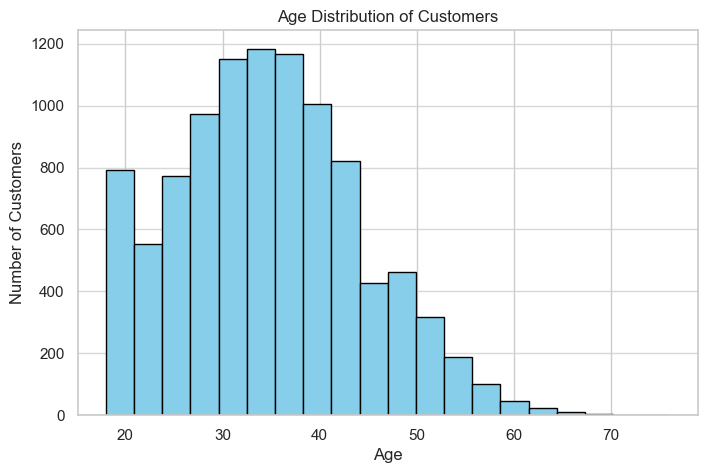

In [10]:
# Get descriptive statistics
age_desc = df_customers["age"].describe()
print("Descriptive statistics for customer age:\n", age_desc)

# Plot the histogram
plt.figure(figsize=(8, 5))
df_customers["age"].hist(bins=20, color='skyblue', edgecolor='black')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid(axis='y', alpha=0.75)
plt.show()


In [11]:
# Skewness and kurtosis for age distribution
age_skewness = df_customers["age"].skew()
age_kurtosis = df_customers["age"].kurt()

print(f"Age skewness: {age_skewness:.3f}")
print(f"Age kurtosis: {age_kurtosis:.3f}")

Age skewness: 0.258
Age kurtosis: -0.305


#### The age distribution looks realistic and consistent with a typical fintech customer base. In 10,000 customers, ages range from 18 to 76, with mean 34.7, median 34, and standard deviation 9.6, indicating a solid concentration around the mid-30s. Skewness is 0.258, showing a mild right tail (slightly more older customers), and kurtosis is -0.305, suggesting a slightly flatter-than-normal shape without heavy tails. Overall, this profile strongly resembles plausible real-world customer age behavior rather than an artificial pattern.

#### How are users distributed across states?

This view shows the number of users in each `state`, helping identify geographic concentration and potential regional opportunities.

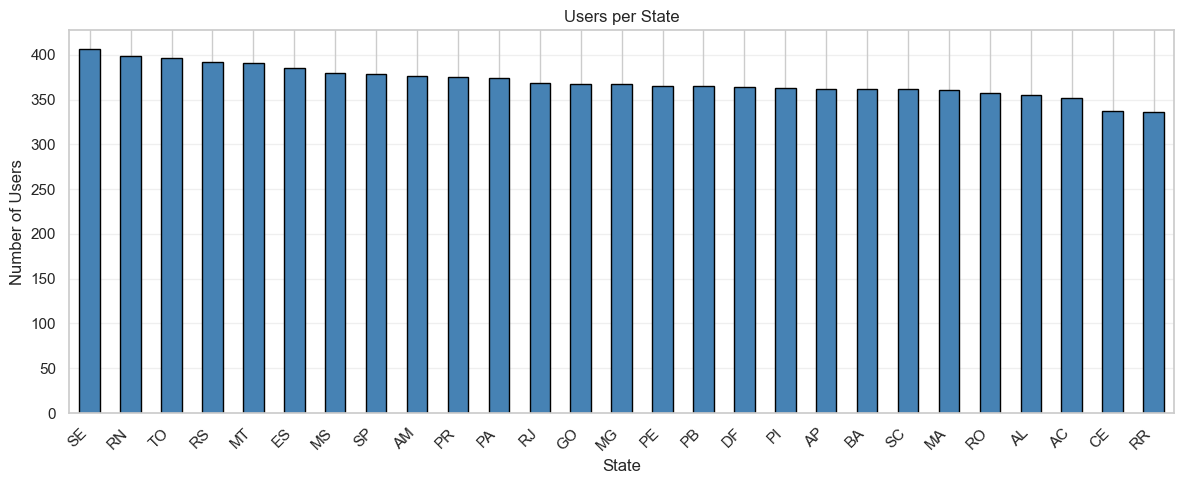

In [12]:
# Users per state
state_counts = df_customers["state"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
state_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Users per State")
plt.xlabel("State")
plt.ylabel("Number of Users")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### <span style="color: red;">The current state distribution does not look realistic for Brazil, because most states appear with very similar user counts. In practice, we would expect stronger concentration in SP, RJ, and the Southeast overall. This will be adjusted in dataset v2 with a weighted geographic distribution.</span>

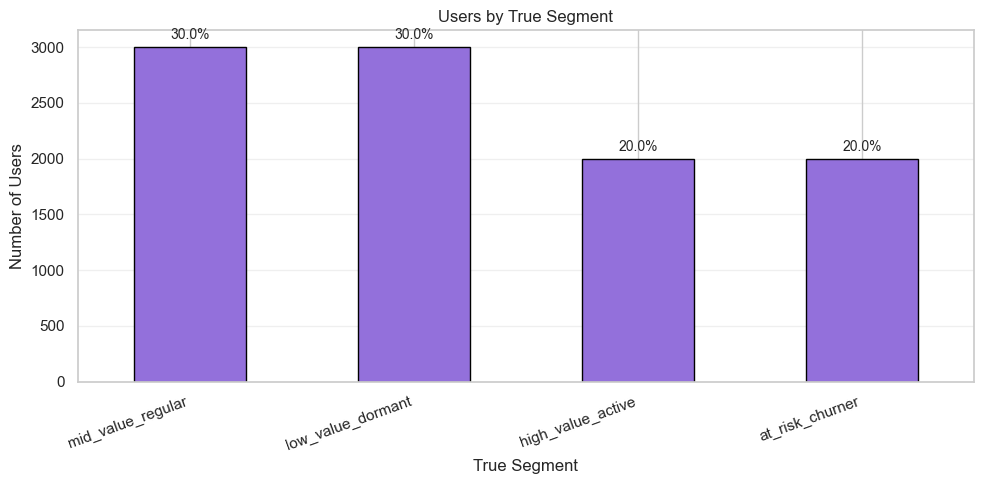

In [19]:
# True segment distribution
segment_counts = df_customers["true_segment"].value_counts().sort_values(ascending=False)
segment_pct = segment_counts / segment_counts.sum() * 100

ax = segment_counts.plot(kind="bar", figsize=(10, 5), color="mediumpurple", edgecolor="black")
plt.title("Users by True Segment")
plt.xlabel("True Segment")
plt.ylabel("Number of Users")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(segment_counts.values):
    ax.text(i, value + (segment_counts.max() * 0.015), f"{segment_pct.iloc[i]:.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

#### True segment distribution is as expected.

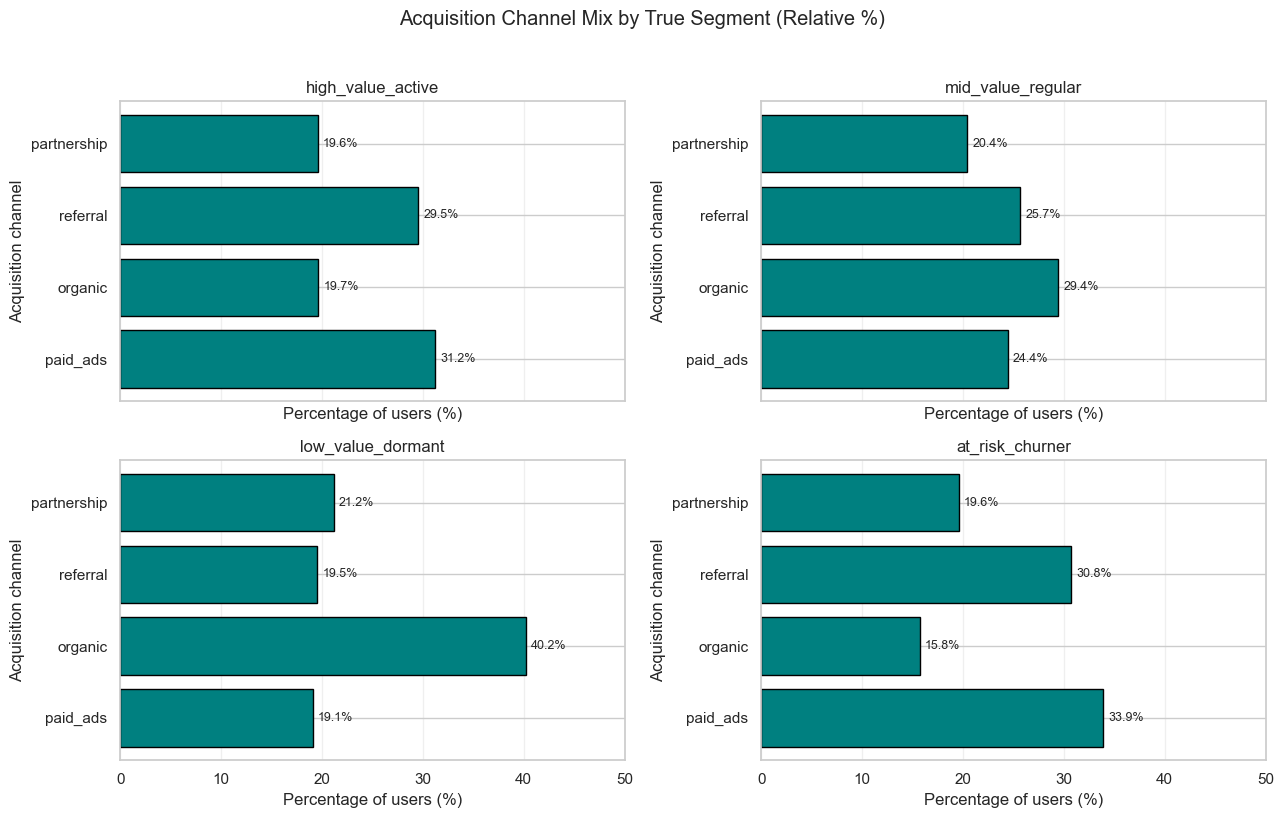

In [18]:
# Acquisition channel distribution by true_segment (relative %)
segment_order = [
    "high_value_active",
    "mid_value_regular",
    "low_value_dormant",
    "at_risk_churner",
]
channel_order = ["paid_ads", "organic", "referral", "partnership"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes = axes.flatten()

for ax, segment in zip(axes, segment_order):
    seg_df = df_customers[df_customers["true_segment"] == segment]
    rel_pct = (
        seg_df["acquisition_channel"]
        .value_counts(normalize=True)
        .reindex(channel_order, fill_value=0)
        .mul(100)
    )

    ax.barh(rel_pct.index, rel_pct.values, color="teal", edgecolor="black")
    ax.set_title(segment)
    ax.set_xlabel("Percentage of users (%)")
    ax.set_ylabel("Acquisition channel")
    ax.set_xlim(0, 50)
    ax.grid(axis="x", alpha=0.3)

    for y, value in enumerate(rel_pct.values):
        ax.text(value + 0.5, y, f"{value:.1f}%", va="center", fontsize=9)

plt.suptitle("Acquisition Channel Mix by True Segment (Relative %)", y=1.02)
plt.tight_layout()
plt.show()

#### Acquisition Channel vs True Segment (Generator Assumptions)

Based on `src/fintech_ai_segmentation/faker_base_generation.py`, channels are sampled in this order:
`paid_ads`, `organic`, `referral`, `partnership`.

Segment-level probabilities:

- `high_value_active`: **30%**, **20%**, **30%**, **20%**
- `mid_value_regular`: **25%**, **30%**, **25%**, **20%**
- `low_value_dormant`: **20%**, **40%**, **20%**, **20%**
- `at_risk_churner`: **35%**, **15%**, **30%**, **20%**

The distributions are aligned with generation assumptions


#### Acquisition Channel Percentage Check vs Intended Design

The table above computes `acquisition_channel` percentages from `df_customers` and compares them with the intended overall design.

Intended overall proportions:

- `paid_ads`: **26.5%**
- `organic`: **28.0%**
- `referral`: **25.5%**
- `partnership`: **20.0%**

These intended values are derived from the segment-specific channel probabilities in the generator, weighted by the intended segment mix (**20% / 30% / 30% / 20%**).

/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_41498/3677521550.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=segment_order, patch_artist=True)


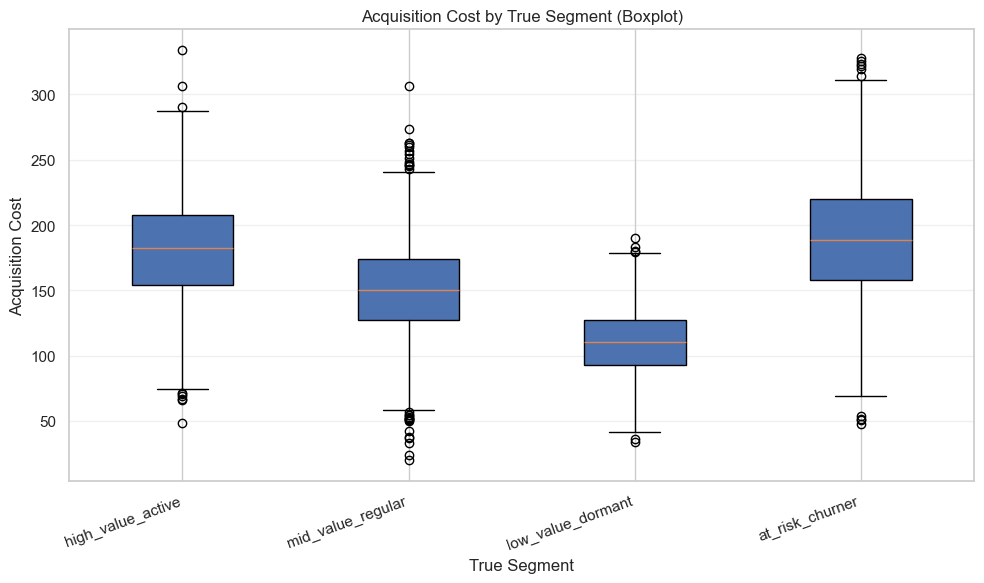

In [23]:
# Acquisition cost comparison by true_segment (boxplot)
segment_order = [
    "high_value_active",
    "mid_value_regular",
    "low_value_dormant",
    "at_risk_churner",
]

boxplot_data = [
    df_customers.loc[df_customers["true_segment"] == segment, "acquisition_cost"]
    for segment in segment_order
]

plt.figure(figsize=(10, 6))
plt.boxplot(boxplot_data, labels=segment_order, patch_artist=True)
plt.title("Acquisition Cost by True Segment (Boxplot)")
plt.xlabel("True Segment")
plt.ylabel("Acquisition Cost")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### The following table compares the observed acquisition cost distribution by true_segment with the generator assumptions. The results are good.

In [22]:
# Comparison with generator assumptions (mean/std by true_segment)
assumptions = {
    "high_value_active": {"expected_mean": 180, "expected_std": 40},
    "mid_value_regular": {"expected_mean": 150, "expected_std": 35},
    "low_value_dormant": {"expected_mean": 110, "expected_std": 25},
    "at_risk_churner": {"expected_mean": 190, "expected_std": 45},
}

observed = (
    df_customers.groupby("true_segment")["acquisition_cost"]
    .agg(observed_mean="mean", observed_std="std", observed_min="min", observed_max="max")
    .round(2)
)

comparison = observed.copy()
comparison["expected_mean"] = comparison.index.map(lambda s: assumptions[s]["expected_mean"])
comparison["expected_std"] = comparison.index.map(lambda s: assumptions[s]["expected_std"])
comparison["mean_diff"] = (comparison["observed_mean"] - comparison["expected_mean"]).round(2)
comparison["std_diff"] = (comparison["observed_std"] - comparison["expected_std"]).round(2)

display(comparison)
print("Note: values should be close to assumptions, with natural sampling variation.")

,observed_mean,observed_std,observed_min,observed_max,expected_mean,expected_std,mean_diff,std_diff
true_segment,,,,,,,,
at_risk_churner,188.69,45.04,47.85,327.75,190,45,-1.31,0.04
high_value_active,180.98,39.89,48.15,334.11,180,40,0.98,-0.11
low_value_dormant,109.85,24.93,33.62,190.38,110,25,-0.15,-0.07
mid_value_regular,150.76,35.10,20.00,306.77,150,35,0.76,0.10


Note: values should be close to assumptions, with natural sampling variation.
